# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [8]:
# mostrar las primeras 5 filas de plans
(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [9]:
# mostrar las primeras 5 filas de users
(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [10]:
# mostrar las primeras 5 filas de usage
(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [11]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [12]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [13]:
# inspección de users con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [14]:
# inspección de usage con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [15]:
# cantidad de nulos para users
print(users.isnull().sum())
print((users.isnull().mean() * 100).round(2))

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [16]:
# cantidad de nulos para usage
print(usage.isnull().sum())
print((usage.isnull().mean() * 100).round(2))

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- churn_date (88.35%) — no es un dato faltante real, sino información válida: significa que el 88.35% de los clientes siguen activos (no se han dado de baja). No se debe imputar ni eliminar, se debe interpretar como una categoría ("activo" vs "con fecha de churn").
-duration y length en usage — tampoco son nulos "reales": cada fila es una llamada (tiene duration) o un mensaje (tiene length), nunca ambos. Por eso cada columna tiene ~45-55% de nulos — son mutuamente excluyentes por diseño, no datos perdidos.
-city (11.72%) — este sí es un nulo genuino que probablemente haya que tratar en la limpieza.
-date (0.12%) — muy pocos casos, fácil de decidir (eliminar esas filas o investigar por qué faltan).

- Indica qué harías: ¿imputar, eliminar, ignorar?
ignoraria "churn date", ignoraria "duration/lenght", imputaria "city"

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [17]:
# explorar columnas numéricas de users
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` user_id: va de 10,000 a 13,999 (es solo un identificador, sin interpretación estadística real).
  
- La columna `age` aquí está el hallazgo importante — el mínimo es -999, una edad imposible que es un valor placeholder de error/dato faltante, no un dato real. Esto también dispara la desviación estándar (123 años) muy por encima de lo esperado. El resto de las edades va de forma razonable entre ~18 y 79 años. Hay que limpiar este valor antes de cualquier análisis por edad.

In [18]:
# explorar columnas numéricas de usage
(usage[['id', 'user_id']].describe())

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`, 40,000 valores únicos para 40,000 filas — es un identificador propio de cada registro de uso (llamada o mensaje), sin duplicados. Va de 1 a 40,000 de forma consecutiva.

user_id: solo 3,999 valores únicos, aunque users tiene 4,000 clientes — es decir, hay un cliente que nunca usó el servicio (ni hizo llamadas ni envió mensajes en el período analizado). Vale la pena identificar cuál para no perderlo de vista en el análisis de churn/uso.

In [19]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users['plan'].unique()
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

- La columna `city` dos problemas de calidad — Mezcla nombres completos (Bogotá, Medellín, Cali) con abreviaturas (CDMX, GDL, MTY), probablemente representando las mismas ciudades en formatos distintos.
El valor ? aparece 96 veces (nulo disfrazado, además de los 469 NaN reales que ya contamos antes).
- La columna `plan` El valor ? aparece 96 veces (nulo disfrazado, además de los 469 NaN reales que ya contamos antes).

In [20]:
# explorar columna categórica de usage
(usage['type'].unique())
(usage['type'].value_counts())

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` solo 2 valores (call, text), consistente con lo esperado — 22,092 mensajes y 17,908 llamadas, sin valores inesperados.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 
Caso: ID
Que veo: 40,000 valores únicos para 40,000 filas, sin duplicados — es simplemente el identificador de cada evento de uso (llamada o mensaje).
Acción que recomendaría: Ignorar para el análisis de negocio; solo sirve como llave técnica de la tabla, no aporta información de comportamiento del cliente.

Caso: user_id - valores únicos
Que veo: Solo 3,999 valores únicos, aunque users tiene 4,000 clientes → hay 1 cliente sin ningún registro de uso en el periodo analizado.
Acción que recomendaría: Identificar ese user_id faltante (con un set o isin() comparando ambas tablas) y no eliminarlo de users — es información válida: un cliente inactivo o recién registrado.

Caso: user_id — relación con id (uno a muchos)
Que veo: Cada cliente tiene entre 1 y 27 registros de uso (promedio ~10) — usage es una tabla transaccional, no una fila por cliente.
Acción que recomendaría: Agregar (groupby('user_id')) antes de unir con users — por ejemplo, sumar minutos totales y mensajes totales por cliente — para poder construir un perfil por cliente. Unir sin agregar primero generaría filas duplicadas y estadísticas infladas.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- age, city, duration / lenght, chur
- ¿Qué acción tomarías?
- Para age, convertiría -999 a NaN con .replace(-999, np.nan), y luego decidiría entre imputar con la mediana de edad (~47) o eliminar esas filas, dependiendo de cuántas sean. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print(users['reg_date'].dtypes)
print(users['reg_date'].head())

datetime64[ns]
0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print(usage['date'].dtypes)
print(usage['date'].head())

datetime64[ns]
0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]


In [23]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, la gran mayoría de los registros de clientes se concentran entre 2022 y 2024, de forma muy similar (~1,300 registros por año), lo cual es consistente con el periodo de operación de la empresa. Sin embargo, 40 registros con año 2026, una fecha futura que no puede ser válida ya que los datos solo llegan hasta 2024 — probablemente un error de captura o de generación de datos. Estos casos debemos tratarlos como fechas inválidas (convertirlas a NaT).

In [24]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())

2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
En date, todos los registros válidos caen dentro de 2024, sin fechas futuras ni imposibles — a diferencia de reg_date, aquí no hay valores fuera de rango. Los únicos casos a atender son 50 registros (0.12% del total) con fecha nula, un porcentaje tan bajo que se pueden eliminar sin afectar el análisis. Basaré el análisis de uso en el periodo completo de 2024 que cubren estos datos.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Sí, encontré un caso de año imposible: 40 registros de reg_date (en users) con año 2026 — una fecha futura que  no puede ser válida, ya que el proyecto establece que los datos solo llegan hasta 2024. Es probablemente un error de captura o de generación sintética de datos.
- ¿Qué harías con ellas?
  Convertiría esos 40 registros de reg_date = 2026 a NaT (fecha inválida/nula) en lugar de eliminar las filas completas, ya que el resto de la información de esos clientes (edad, ciudad, plan, historial de uso) sigue siendo válida y útil para el análisis — solo su fecha de registro específica no lo es. Eliminar la fila completa descartaría datos buenos por un solo campo erróneo.

Para los 50 nulos en date (uso), dado que representan apenas 0.12% del total, los eliminaría directamente sin mayor impacto en el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [27]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
(users['reg_date'].isna().sum())
(users['reg_date'].max())

Timestamp('2024-12-31 00:00:00')

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [28]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

type
call        0
text    22076
Name: duration, dtype: int64


In [29]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Verifiqué si los nulos en duration y length dependen de la columna type, y encontré una relación casi perfecta: cuando type == 'call', duration prácticamente nunca es nulo (solo 16 casos) pero length sí lo es en 17,896 registros; y viceversa para type == 'text' (length casi nunca nulo, duration nulo en 22,076 casos).

Esto confirma que los nulos son MAR (Missing At Random): no dependen del valor faltante en sí, sino de otra columna observada (type). Tiene sentido de negocio — una llamada no tiene una "longitud de mensaje" que reportar, y un mensaje no tiene una "duración de llamada".

Decisión: dejaría ambas columnas con sus nulos tal cual, sin imputar. Para el análisis, filtraría por type antes de trabajar con duration o length (ej. usage[usage['type']=='call']['duration']).

Los pocos casos que no encajan en el patrón (16 llamadas sin duration, 12 mensajes sin length) sí representan nulos genuinos — menos del 0.1% del total — y se pueden dejar como están o eliminar sin impacto relevante en el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [33]:
# Resumen estadístico de las columnas numéricas
(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [34]:
# Distribución porcentual del tipo de plan
(user_profile['plan'].value_counts(normalize=True) * 100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

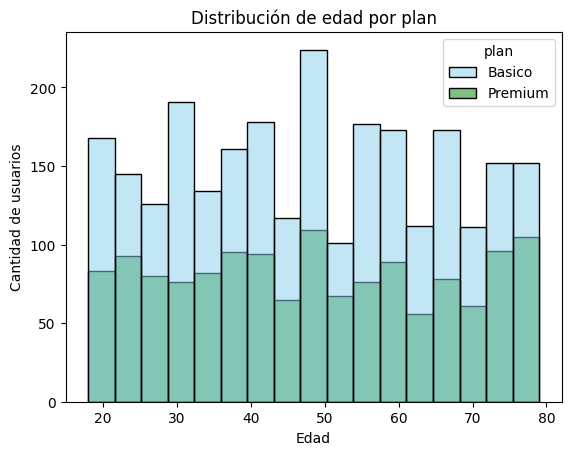

In [35]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Lla distribución de edad es prácticamente simétrica (sin sesgo marcado), con clientes bien distribuidos entre 18 y 79 años. No se observa un patrón claro entre edad y tipo de plan — la proporción de Básico vs. Premium se mantiene similar en todos los rangos de edad, lo que sugiere que la edad no es un factor determinante en la elección del plan.

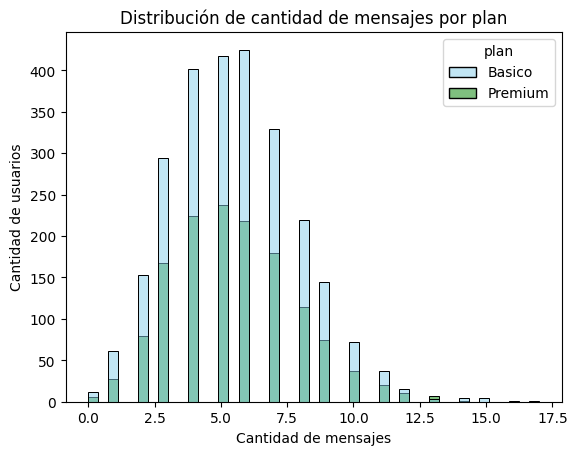

In [36]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: Distribución con sesgo leve a la derecha (la mayoría de usuarios envía entre 3 y 8 mensajes, con una cola de pocos usuarios que envían más). No existe un patrón diferenciado por plan — ambos grupos siguen una forma muy similar, solo que Básico tiene más usuarios en términos absolutos (consistente con que representa el 65% de la base).
- ....

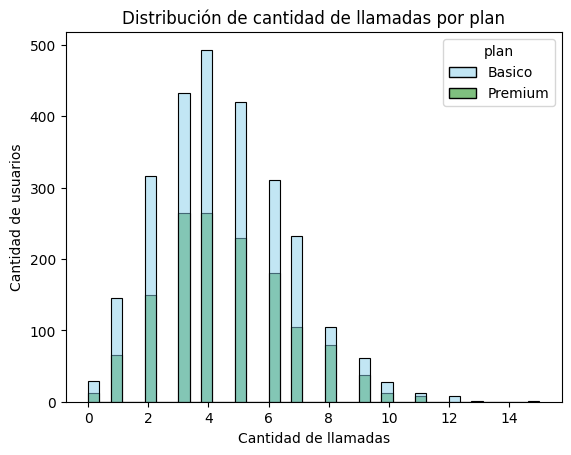

In [37]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución con sesgo a la derecha, similar a mensajes — la mayoría hace entre 2 y 6 llamadas. Tampoco hay diferencia notable entre planes Básico y Premium: ambos tienden a hacer una cantidad similar de llamadas proporcionalmente.

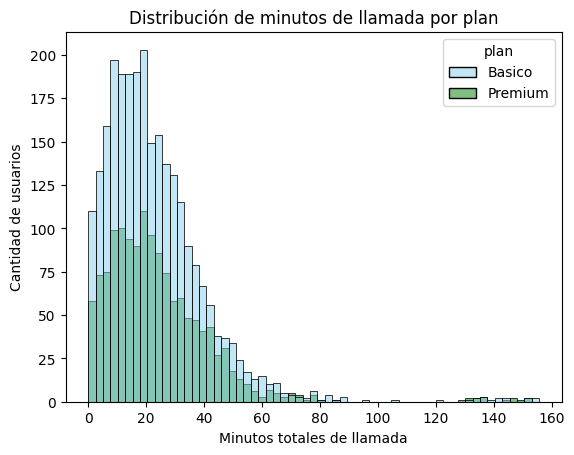

In [38]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Esta variable es la que mayor sesgo a la derecha de las cuatro (la mayoría concentrado entre 0 y 40 minutos, con una cola larga de usuarios que acumulan hasta 150+ minutos). Tampoco existe un patrón claro por plan — dentro del plan Premium no hay mayor proporción de usuarios con muchos minutos, contrario a lo que se podría esperar de un plan "superior".

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

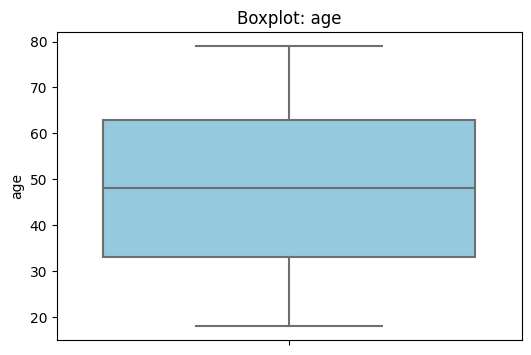

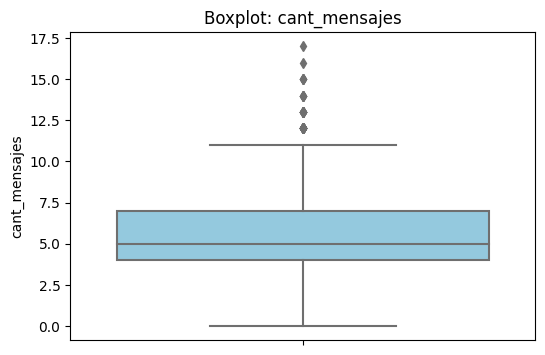

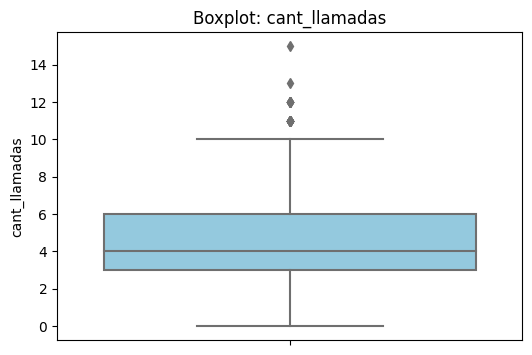

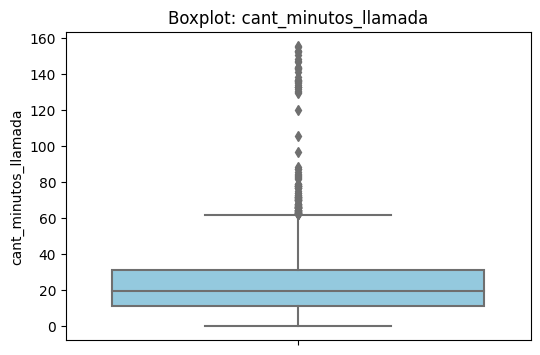

In [39]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers — todos los valores caen dentro de los bigotes (18 a 79 años), consistente con la distribución simétrica que vimos en el histograma.
- cant_mensajes: sí presenta outliers, todos por el lado superior (usuarios con 12 a 17 mensajes, por encima del bigote superior en ~11).
- cant_llamadas: sí presenta outliers, también solo por el lado superior (usuarios con 11 a 15 llamadas, por encima del bigote en ~10).
- cant_minutos_llamada: es la que presenta más outliers y más extremos, todos también del lado superior — una cola larga de usuarios que acumulan entre 60 y 155 minutos, muy por encima del resto.

In [40]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

limites_superiores = {}
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limites_superiores[col] = Q3 + 1.5 * IQR   # solo límite superior: son outliers de un solo lado

print(limites_superiores)


{'cant_mensajes': 11.5, 'cant_llamadas': 10.5, 'cant_minutos_llamada': 61.8575}


In [41]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()
print(limites_superiores)


{'cant_mensajes': 11.5, 'cant_llamadas': 10.5, 'cant_minutos_llamada': 61.8575}


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
(límite superior ≈ 11.5): 46 usuarios (1.15%) por encima — mantener. Son pocos casos y no es imposible que un cliente envíe hasta 17 mensajes en el periodo; no hay evidencia de error de captura, solo son usuarios más activos.
- cant_llamadas: mantener o no outliers, porqué?
(límite superior ≈ 10.5): 30 usuarios (0.75%) por encima — mantener, mismo razonamiento: son valores altos pero plausibles (máx. 15 llamadas), no hay señal de dato erróneo.
- cant_minutos_llamada: mantener o no outliers, porqué?
(límite superior ≈ 61.9): 109 usuarios (2.73%) por encima, con máximo de 155.7 min — mantener también. Aunque es la variable con más outliers, siguen siendo valores de negocio realistas (usuarios que hablan mucho por teléfono), no valores imposibles como el -999 que sí corregimos en age. Eliminarlos descartaría información legítima sobre los clientes de mayor uso, que además pueden ser relevantes para el análisis de comportamiento y churn.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [46]:
import numpy as np

# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [48]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]
valores = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')

In [49]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

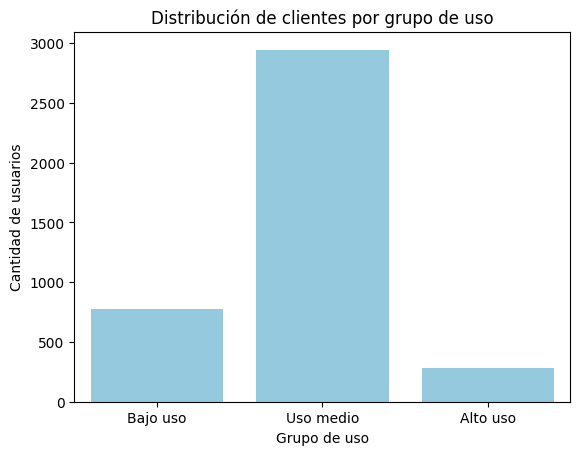

In [50]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso','Uso medio','Alto uso'], color='skyblue')
plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

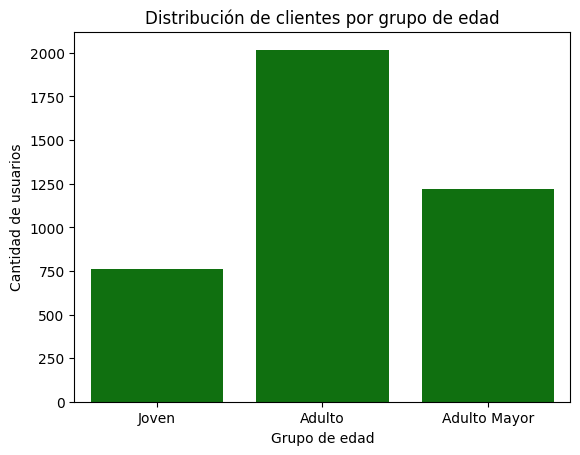

In [51]:

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven','Adulto','Adulto Mayor'], color='green')
plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Encontré cuatro problemas principales: (1) la columna age contenía el valor centinela -999 como marcador de dato faltante/erróneo; (2) city tenía 469 nulos reales más 96 valores "?" (nulo disfrazado) — 565 registros (14.1%) en total, además de inconsistencia de formato (nombres completos mezclados con abreviaturas); (3) reg_date tenía 40 registros (1%) con año 2026, una fecha futura imposible; y (4) usage tenía nulos "estructurales" en duration y length (55% y 45% respectivamente), que resultaron ser MAR — dependientes de la columna type, no errores reales.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

   Segmenté a los clientes en dos dimensiones: por edad (Joven <30, Adulto 30-59, Adulto Mayor 60+) y por nivel de uso (Bajo, Medio, Alto, según llamadas y mensajes). Lo más notable es que el nivel de uso es prácticamente idéntico entre los tres grupos de edad (todos alrededor de 72-74% en "Uso medio", 6-8% en "Alto uso"). Esto indica que la edad no predice el comportamiento de uso en esta base de clientes — un adulto mayor usa el servicio de forma tan intensa como un joven.

  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

    El segmento de "Alto uso" (6.95% de la base, 278 clientes) es el más valioso: consume en promedio más del doble de minutos que el grupo de "Bajo uso" (30.1 vs. 14.9 minutos), lo que sugiere mayor dependencia del servicio y, potencialmente, mayor disposición a pagar por planes superiores o servicios adicionales. Sin embargo, un hallazgo clave es que el tipo de plan (Básico/Premium) no varía según el nivel de uso (66.5% Básico en "Alto uso" vs. 64.5% en "Uso medio") — es decir, los clientes de alto consumo no están migrando proporcionalmente al plan Premium, lo que representa una oportunidad comercial desaprovechada.

  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Detecté outliers de un solo lado (superior) en cant_mensajes (46 clientes, >11 mensajes), cant_llamadas (30 clientes, >10 llamadas) y especialmente en cant_minutos_llamada (109 clientes, >62 minutos, hasta 155.7 min). Decidí conservarlos porque son valores de negocio realistas, no errores de captura. Estos clientes representan a los usuarios más intensivos del servicio — un grupo pequeño pero desproporcionadamente activo, ideal para estrategias de retención dirigidas o upselling hacia planes con más minutos/beneficios.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Crear un plan "Ilimitado" o "Alto Consumo" dirigido específicamente al 7% de clientes en el segmento de "Alto uso" y a los outliers de minutos de llamada, ya que actualmente estos usuarios de alto consumo no muestran mayor propensión a tener Premium — sugiere que el plan actual no está capturando ese valor adicional.
No segmentar campañas por edad, ya que el comportamiento de uso es homogéneo entre grupos etarios; en cambio, segmentar por nivel de uso real (Bajo/Medio/Alto), que sí muestra diferencias significativas en minutos consumidos y es un mejor predictor de necesidades del cliente.

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc
Antes de segmentar, fue necesario resolver varios problemas de calidad en los datos: la columna age contenía el valor centinela -999 como marcador de error (corregido con la mediana, 48 años); city tenía 565 registros (14.1%) con valores faltantes o disfrazados ("?") y nombres inconsistentes (abreviaturas vs. nombres completos); reg_date incluía 40 registros (1%) con año 2026, una fecha futura imposible que se marcó como nula; y los nulos "estructurales" en duration/length de usage (55% y 45%) resultaron ser MAR —dependientes del tipo de evento (llamada o mensaje)— por lo que se dejaron intactos en vez de imputarse.

🔍 **Segmentos por Edad**
- abc
- abc 
Con los datos limpios, construí un perfil de uso por cliente y lo segmenté en dos dimensiones: grupo de edad (Joven, Adulto, Adulto Mayor) y grupo de uso (Bajo, Medio, Alto, según llamadas y mensajes). El hallazgo más relevante es que la edad no predice el comportamiento de uso: los tres grupos etarios muestran una distribución de uso casi idéntica (72-74% en "Uso medio" en los tres casos), lo que descarta a la edad como criterio útil de segmentación comercial.

📊 **Segmentos por Nivel de Uso**
- abc
- abc
En cambio, el grupo de uso sí revela diferencias de negocio significativas. El segmento de "Alto uso" (6.95% de la base, 278 clientes) consume en promedio más del doble de minutos que el de "Bajo uso" (30.1 vs. 14.9 min), lo que lo convierte en el segmento más valioso por su nivel de dependencia del servicio. Sin embargo, la proporción de clientes con plan Premium es prácticamente la misma en todos los grupos de uso (~34-36%), lo que indica que el consumo intensivo no se está traduciendo en mayor adopción del plan superior — una oportunidad comercial desaprovechada.

➡️ Esto sugiere que ...
Este patrón se refuerza con los outliers identificados: 109 clientes (2.7%) superan los 62 minutos de llamada (hasta 155.7 min), y otros ~46-30 clientes destacan en mensajes y llamadas respectivamente. Se decidió conservar estos valores extremos por ser comportamientos de negocio legítimos, no errores de captura — representan a los usuarios más intensivos, un grupo pequeño pero con alto potencial de ingreso.

💡 **Recomendaciones**
- abc
- abc
(1) crear un plan de "Alto Consumo" o "Ilimitado" dirigido específicamente al segmento de "Alto uso" y a los outliers de minutos, ya que el plan Premium actual no está capturando ese valor adicional; y (2) reorientar la segmentación comercial de ConnectaTel de criterios demográficos (edad) hacia criterios de comportamiento real (nivel de uso), que demostraron ser un predictor mucho más fuerte de las necesidades y el valor del cliente.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`